# Q-Learning vs. sin Q-Learning
## Comparando cómo un agente aprende a decidir "aceptar o esperar"

Este notebook aísla un único componente del sistema multiagente de
`sistema_multiagente.ipynb` (secciones 4.1 y 8.2): la decisión de un agente,
en cada ronda `t`, de **aceptar** la mejor candidata disponible (utilidad `u`)
o **esperar** una ronda más con la esperanza de algo mejor, antes del deadline `τ`.

Se comparan **tres formas de resolver esa misma decisión**:

| Política | Cómo se obtiene | ¿Aprende? |
|---|---|---|
| **Bellman óptima** `u*(t)` | Planificación exacta (inducción hacia atrás), requiere conocer el modelo (`T`, `R`, distribución de `u`) | No -- se calcula, no se aprende |
| **Heurística** `φ(t)` | Fórmula cerrada, la que de verdad usan los agentes (`umbral_aceptacion`) | No -- **esta es la política "sin Q-learning"** |
| **Q-learning** `π_Q` | Ensayo-error sobre episodios simulados, sin conocer el modelo | **Sí -- esta es la política "con Q-learning"** |

El objetivo es mostrar, con el mínimo de gráficas necesarias, en qué se parecen,
en qué difieren y cuánto tarda Q-learning en alcanzar a las otras dos.

In [8]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

random.seed(7)
np.random.seed(7)

# Paleta consistente con sistema_multiagente.ipynb (sección 10)
CAT = {
    "blue": "#2a78d6", "orange": "#eb6834", "aqua": "#1baf7a", "yellow": "#eda100",
    "magenta": "#e87ba4", "green": "#008300", "violet": "#4a3aa7", "red": "#e34948",
}
INK, INK_2, MUTED, GRID, SURFACE = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#fcfcfb"
GOOD, CRITICAL = "#0ca30c", "#d03b3b"
SEQ_BLUE = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"]
CMAP_SEQ = plt.matplotlib.colors.LinearSegmentedColormap.from_list("seqblue", SEQ_BLUE)

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "axes.edgecolor": GRID,
    "axes.labelcolor": INK_2, "text.color": INK, "xtick.color": MUTED, "ytick.color": MUTED,
    "grid.color": GRID, "axes.grid": False,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 10.5, "figure.dpi": 100,
})

# --- Parámetros del MDP de aceptar/esperar (sección 4.1 / 8.2 del notebook original) ---
NIVELES_UTILIDAD = [0.0, 20.0, 40.0, 60.0, 80.0, 100.0]  # discretización de u
TAU = 8                 # deadline: rondas 0..TAU-1, terminal en TAU
GAMMA = 0.9              # descuento
COSTO_ESPERA = 2.0       # coste de esperar una ronda
VALOR_RESERVA = 10.0     # r_i: utilidad de no reunirse
ASPIRACION_INICIAL = 100.0
ALPHA_CONCESION = 1.0    # estilo de concesión neutro (φ_i^0, sección 8)

print(f"tau={TAU}, gamma={GAMMA}, costo_espera={COSTO_ESPERA}, valor_reserva={VALOR_RESERVA}")
print(f"niveles de utilidad posibles: {NIVELES_UTILIDAD}")

tau=8, gamma=0.9, costo_espera=2.0, valor_reserva=10.0
niveles de utilidad posibles: [0.0, 20.0, 40.0, 60.0, 80.0, 100.0]


## 1. Las dos políticas "sin Q-learning"

**Bellman óptima** resuelve el MDP por planificación exacta (sección 4.1): asume
que conoce `T`, `R` y la distribución de `u`, e induce hacia atrás desde `τ`.

**Heurística** `φ(t)` (la que de verdad usa `AgenteProxy.umbral_aceptacion` en la
simulación) es una forma cerrada mucho más barata: decrece monótonamente desde la
aspiración inicial hasta el valor de reserva, sin resolver ninguna ecuación de
Bellman ni necesitar conocer la distribución de `u`.

Ninguna de las dos **aprende**: ambas están fijadas antes de que empiece el episodio.

In [9]:
def valor_iteracion_umbral(niveles_utilidad, tau, gamma, costo_espera, valor_reserva):
    '''Bellman por induccion hacia atras: umbral optimo u*(t) para cada ronda t.'''
    v_siguiente = valor_reserva
    umbrales = {}
    for t in range(tau - 1, -1, -1):
        umbral = -costo_espera + gamma * v_siguiente
        umbrales[t] = umbral
        v_siguiente = sum(max(u, umbral) for u in niveles_utilidad) / len(niveles_utilidad)
    return dict(sorted(umbrales.items()))


def umbral_heuristico(t, tau, valor_reserva=VALOR_RESERVA,
                       aspiracion_inicial=ASPIRACION_INICIAL, alpha=ALPHA_CONCESION):
    '''phi(t) -- la formula cerrada que usa AgenteProxy.umbral_aceptacion, sin aprendizaje.'''
    tau = max(tau, 1)
    frac = max(0.0, 1 - t / tau)
    return valor_reserva + (aspiracion_inicial - valor_reserva) * (frac ** alpha)


umbral_bellman = valor_iteracion_umbral(NIVELES_UTILIDAD, TAU, GAMMA, COSTO_ESPERA, VALOR_RESERVA)
umbral_heur = {t: umbral_heuristico(t, TAU) for t in range(TAU)}

pd.DataFrame([
    {"t": t, "umbral_bellman (u*)": round(umbral_bellman[t], 1),
     "umbral_heuristico (phi)": round(umbral_heur[t], 1)}
    for t in range(TAU)
])

,t,umbral_bellman (u*),umbral_heuristico (phi)
0,0,62.0,100.0
1,1,61.7,88.8
2,2,61.1,77.5
3,3,60.2,66.2
4,4,58.2,55.0
5,5,53.8,43.8
6,6,44.0,32.5
7,7,7.0,21.2


## 2. La política "con Q-learning"

Q-learning tabular resuelve el mismo MDP **sin conocer el modelo**: solo observa
episodios `(estado, acción, recompensa, estado siguiente)` y actualiza

```
Q(s, a) <- Q(s, a) + alpha * [ r + gamma * max_a' Q(s', a') - Q(s, a) ]
```

Para poder animar la convergencia (sección 4), el entrenamiento guarda una
**fotografía de la tabla Q** en varios puntos de control (de 0 a 30&nbsp;000 episodios).

In [10]:
ACCIONES_QL = ["aceptar", "esperar"]
CHECKPOINTS = [0, 50, 150, 400, 1000, 2500, 6000, 15000, 30000]


def entrenar_q_learning_con_checkpoints(tau, gamma, costo_espera, valor_reserva,
                                         checkpoints, alpha=0.1, epsilon=0.2, semilla=42):
    '''Q-learning tabular sobre el MDP de aceptar/esperar, con arranque exploratorio
    (t inicial aleatorio) para cubrir tambien las rondas tardias. Devuelve una foto de Q
    en cada episodio listado en `checkpoints`.'''
    rng = random.Random(semilla)
    Q = {(t, u): {"aceptar": 0.0, "esperar": 0.0} for t in range(tau) for u in NIVELES_UTILIDAD}
    checkpoints_set = set(checkpoints)
    fotos = {}
    if 0 in checkpoints_set:
        fotos[0] = {k: dict(v) for k, v in Q.items()}

    for episodio in range(1, max(checkpoints) + 1):
        t = rng.randrange(tau)
        u = rng.choice(NIVELES_UTILIDAD)
        while True:
            estado = (t, u)
            accion = (rng.choice(ACCIONES_QL) if rng.random() < epsilon
                      else max(Q[estado], key=Q[estado].get))

            if accion == "aceptar":
                recompensa_obs, fin = u, True
            else:
                recompensa_obs, fin = -costo_espera, (t + 1 >= tau)

            if fin:
                objetivo = (recompensa_obs if accion == "aceptar"
                            else recompensa_obs + gamma * valor_reserva)
                Q[estado][accion] += alpha * (objetivo - Q[estado][accion])
                break

            t_siguiente = t + 1
            u_siguiente = rng.choice(NIVELES_UTILIDAD)
            mejor_siguiente = max(Q[(t_siguiente, u_siguiente)].values())
            objetivo = recompensa_obs + gamma * mejor_siguiente
            Q[estado][accion] += alpha * (objetivo - Q[estado][accion])
            t, u = t_siguiente, u_siguiente

        if episodio in checkpoints_set:
            fotos[episodio] = {k: dict(v) for k, v in Q.items()}

    return fotos


fotos_q = entrenar_q_learning_con_checkpoints(TAU, GAMMA, COSTO_ESPERA, VALOR_RESERVA, CHECKPOINTS)
Q_final = fotos_q[CHECKPOINTS[-1]]

politica_q_final = pd.DataFrame([
    {"t": t, "u": u, "accion_q": max(Q_final[(t, u)], key=Q_final[(t, u)].get)}
    for t in range(TAU) for u in NIVELES_UTILIDAD
])
print(f"Q-learning entrenado con checkpoints en episodios: {CHECKPOINTS}")

Q-learning entrenado con checkpoints en episodios: [0, 50, 150, 400, 1000, 2500, 6000, 15000, 30000]


## 3. Gráfica 1 -- rejilla de decisión: las tres políticas lado a lado

Cada celda es una decisión `(t, u) -> {aceptar, esperar}`. Si Q-learning aprendió
bien, su rejilla debería parecerse mucho a la de Bellman (la solución exacta) y
razonablemente a la heurística (que es solo una aproximación barata de esa misma
forma).

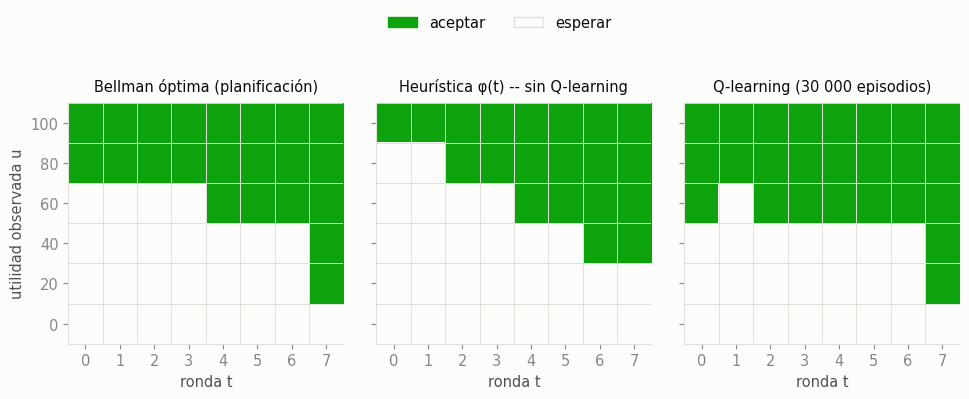

Coincidencia con Bellman -- heurística (sin Q-learning): 92%
Coincidencia con Bellman -- Q-learning:                  94%


In [11]:
def rejilla_decision(decide_fn):
    '''decide_fn(t, u) -> True (aceptar) / False (esperar). Filas = u desc, columnas = t.'''
    niveles_desc = sorted(NIVELES_UTILIDAD, reverse=True)
    mat = np.zeros((len(niveles_desc), TAU))
    for i, u in enumerate(niveles_desc):
        for t in range(TAU):
            mat[i, t] = 1.0 if decide_fn(t, u) else 0.0
    return mat, niveles_desc


def _pintar_rejilla(ax, mat, niveles_desc, titulo):
    cmap_binario = plt.matplotlib.colors.ListedColormap([SURFACE, GOOD])
    ax.imshow(mat, cmap=cmap_binario, vmin=0, vmax=1, aspect="auto")
    ax.set_xticks(range(TAU)); ax.set_xticklabels(range(TAU))
    ax.set_yticks(range(len(niveles_desc))); ax.set_yticklabels([int(u) for u in niveles_desc])
    ax.set_xlabel("ronda t")
    for i in range(len(niveles_desc)):
        for j in range(TAU):
            ax.add_patch(mpatches.Rectangle((j - 0.5, i - 0.5), 1, 1, fill=False,
                                             edgecolor=GRID, linewidth=0.6))
    ax.set_title(titulo, fontsize=10.5, pad=8)


decide_bellman = lambda t, u: u >= umbral_bellman[t]
decide_heur = lambda t, u: u >= umbral_heur[t]
decide_q = lambda t, u: max(Q_final[(t, u)], key=Q_final[(t, u)].get) == "aceptar"

fig1, axes1 = plt.subplots(1, 3, figsize=(11.5, 3.6), sharey=True)
for ax, decide_fn, titulo in zip(
    axes1,
    [decide_bellman, decide_heur, decide_q],
    ["Bellman óptima (planificación)", "Heurística φ(t) -- sin Q-learning", "Q-learning (30 000 episodios)"],
):
    mat, niveles_desc = rejilla_decision(decide_fn)
    _pintar_rejilla(ax, mat, niveles_desc, titulo)
axes1[0].set_ylabel("utilidad observada u")

handles = [mpatches.Patch(color=GOOD, label="aceptar"),
           mpatches.Patch(facecolor=SURFACE, edgecolor=GRID, label="esperar")]
fig1.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, 1.06), ncol=2, frameon=False)
fig1.subplots_adjust(top=0.78, wspace=0.12)
plt.show()

coincidencia_heur = np.mean(rejilla_decision(decide_bellman)[0] == rejilla_decision(decide_heur)[0])
coincidencia_q = np.mean(rejilla_decision(decide_bellman)[0] == rejilla_decision(decide_q)[0])
print(f"Coincidencia con Bellman -- heurística (sin Q-learning): {coincidencia_heur:.0%}")
print(f"Coincidencia con Bellman -- Q-learning:                  {coincidencia_q:.0%}")

## 4. Gráfica 2 -- curva de aprendizaje

La heurística y Bellman no cambian con el tiempo: son una línea de referencia
horizontal. Q-learning sí: cada punto evalúa, por Monte Carlo, el retorno medio
de la política **greedy** leída de la tabla Q tal como estaba en ese checkpoint
de entrenamiento.

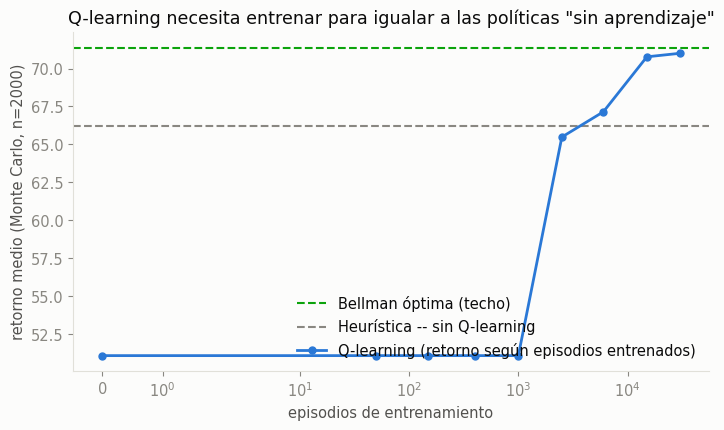

Retorno medio -- Bellman óptima:     71.38
Retorno medio -- Heurística:         66.21
Retorno medio -- Q-learning (final):  71.00
Retorno medio -- Q-learning (ep=50): 51.09  <- apenas ha aprendido


In [12]:
def simular_episodio(decide_fn, tau, gamma, costo_espera, valor_reserva, rng):
    '''Un episodio bajo una politica decide_fn(t, u)->bool, empezando en t=0.
    Devuelve el retorno descontado.'''
    t = 0
    descuento = 1.0
    retorno = 0.0
    while True:
        u = rng.choice(NIVELES_UTILIDAD)
        if decide_fn(t, u):
            retorno += descuento * u
            return retorno
        retorno += descuento * (-costo_espera)
        t += 1
        descuento *= gamma
        if t >= tau:
            retorno += descuento * valor_reserva
            return retorno


def evaluar_politica(decide_fn, n_episodios=3000, semilla=0):
    rng = random.Random(semilla)
    retornos = [simular_episodio(decide_fn, TAU, GAMMA, COSTO_ESPERA, VALOR_RESERVA, rng)
                for _ in range(n_episodios)]
    return np.array(retornos)


retorno_bellman = evaluar_politica(decide_bellman).mean()
retorno_heur = evaluar_politica(decide_heur).mean()

curva_episodios, curva_retorno = [], []
for ep in CHECKPOINTS:
    Q_foto = fotos_q[ep]
    decide_foto = lambda t, u, Qf=Q_foto: max(Qf[(t, u)], key=Qf[(t, u)].get) == "aceptar"
    curva_episodios.append(ep)
    curva_retorno.append(evaluar_politica(decide_foto, n_episodios=2000, semilla=1).mean())

fig2, ax2 = plt.subplots(figsize=(8.2, 4.4))
ax2.axhline(retorno_bellman, color=GOOD, linestyle="--", linewidth=1.5, label="Bellman óptima (techo)")
ax2.axhline(retorno_heur, color=MUTED, linestyle="--", linewidth=1.5, label="Heurística -- sin Q-learning")
ax2.plot(curva_episodios, curva_retorno, color=CAT["blue"], linewidth=2, marker="o", markersize=5,
         label="Q-learning (retorno según episodios entrenados)")
ax2.set_xscale("symlog")
ax2.set_xlabel("episodios de entrenamiento")
ax2.set_ylabel("retorno medio (Monte Carlo, n=2000)")
ax2.set_title("Q-learning necesita entrenar para igualar a las políticas \"sin aprendizaje\"")
ax2.legend(frameon=False, loc="lower right")
plt.show()

print(f"Retorno medio -- Bellman óptima:     {retorno_bellman:.2f}")
print(f"Retorno medio -- Heurística:         {retorno_heur:.2f}")
print(f"Retorno medio -- Q-learning (final):  {curva_retorno[-1]:.2f}")
print(f"Retorno medio -- Q-learning (ep={CHECKPOINTS[1]}): {curva_retorno[1]:.2f}  <- apenas ha aprendido")

## 5. Animación -- la rejilla aprendida convergiendo

Se reproduce, fotograma a fotograma, la rejilla de decisión de Q-learning en cada
checkpoint de entrenamiento, con el contorno de la rejilla de Bellman superpuesto
como referencia. Al principio (pocos episodios) la tabla Q está casi vacía y la
política es prácticamente aleatoria; hacia el final debería encajar con el
contorno óptimo.

In [13]:
mat_bellman, niveles_desc = rejilla_decision(decide_bellman)
cmap_binario = plt.matplotlib.colors.ListedColormap([SURFACE, GOOD])

fig3, ax3 = plt.subplots(figsize=(6.6, 4.2))


def render_frame(idx):
    ax3.clear()
    ep = CHECKPOINTS[idx]
    Q_foto = fotos_q[ep]
    decide_foto = lambda t, u, Qf=Q_foto: max(Qf[(t, u)], key=Qf[(t, u)].get) == "aceptar"
    mat, _ = rejilla_decision(decide_foto)

    ax3.imshow(mat, cmap=cmap_binario, vmin=0, vmax=1, aspect="auto")
    ax3.set_xticks(range(TAU)); ax3.set_xticklabels(range(TAU))
    ax3.set_yticks(range(len(niveles_desc))); ax3.set_yticklabels([int(u) for u in niveles_desc])
    ax3.set_xlabel("ronda t"); ax3.set_ylabel("utilidad observada u")

    # contorno de la rejilla optima de Bellman, como referencia fija
    for i in range(len(niveles_desc)):
        for j in range(TAU):
            if mat_bellman[i, j] == 1.0:
                ax3.add_patch(mpatches.Rectangle((j - 0.5, i - 0.5), 1, 1, fill=False,
                                                  edgecolor=INK, linewidth=1.6))

    coincidencia = np.mean(mat == mat_bellman)
    ax3.set_title(f"Q-learning tras {ep:,} episodios -- coincidencia con Bellman: {coincidencia:.0%}",
                  fontsize=10.5)


anim = FuncAnimation(fig3, render_frame, frames=len(CHECKPOINTS), interval=1000, repeat=False)
resultado_animacion = HTML(anim.to_jshtml())
plt.close(fig3)
resultado_animacion

## 6. Resultado final -- distribución de retorno, sin Q-learning vs con Q-learning

Por último, 5&nbsp;000 episodios de Monte Carlo por política, comparando la
**distribución completa** de retorno (no solo la media): ¿Q-learning no solo
alcanza en promedio a la heurística, sino que además es igual de consistente?

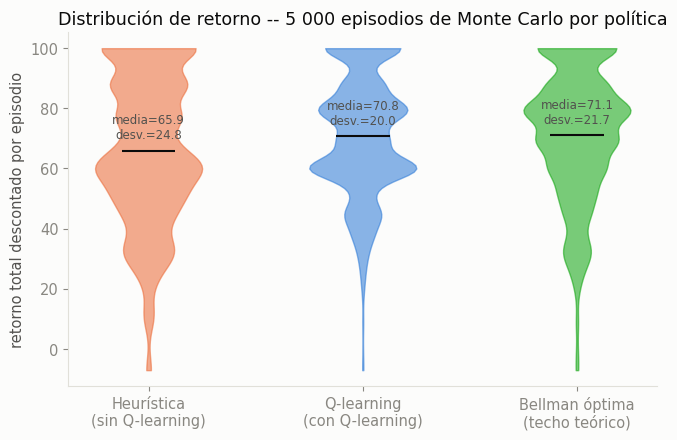

,política,media,desv_estándar
0,Heurística (sin Q-learning),65.89,24.78
1,Q-learning (con Q-learning),70.83,20.04
2,Bellman óptima (techo teórico),71.09,21.75


In [14]:
politicas_finales = {
    "Heurística\n(sin Q-learning)": decide_heur,
    "Q-learning\n(con Q-learning)": decide_q,
    "Bellman óptima\n(techo teórico)": decide_bellman,
}
colores_final = [CAT["orange"], CAT["blue"], GOOD]

retornos_finales = [evaluar_politica(fn, n_episodios=5000, semilla=7) for fn in politicas_finales.values()]

fig4, ax4 = plt.subplots(figsize=(7.6, 4.6))
partes = ax4.violinplot(retornos_finales, showmeans=True, showextrema=False)
for cuerpo, color in zip(partes["bodies"], colores_final):
    cuerpo.set_facecolor(color); cuerpo.set_alpha(0.55); cuerpo.set_edgecolor(color)
partes["cmeans"].set_color(INK); partes["cmeans"].set_linewidth(1.5)

ax4.set_xticks(range(1, len(politicas_finales) + 1))
ax4.set_xticklabels(list(politicas_finales.keys()))
ax4.set_ylabel("retorno total descontado por episodio")
ax4.set_title("Distribución de retorno -- 5 000 episodios de Monte Carlo por política")

for x, retornos in enumerate(retornos_finales, start=1):
    ax4.text(x, retornos.mean() + 4, f"media={retornos.mean():.1f}\ndesv.={retornos.std():.1f}",
              ha="center", fontsize=8.5, color=INK_2)

plt.show()

resumen_final = pd.DataFrame([
    {"política": nombre.replace("\n", " "), "media": round(r.mean(), 2), "desv_estándar": round(r.std(), 2)}
    for nombre, r in zip(politicas_finales.keys(), retornos_finales)
])
resumen_final

## Conclusión

- **Sin Q-learning** hay dos formas de resolver "aceptar o esperar": planificar
  exactamente (Bellman, si se conoce el modelo) o usar una fórmula cerrada barata
  (heurística `φ(t)`) que se le puede anunciar al resto de agentes sin cálculo
  adicional.
- **Con Q-learning** la misma decisión se aprende por ensayo-error, sin conocer
  `T`, `R` ni la distribución de `u` -- a costa de necesitar miles de episodios
  de entrenamiento antes de acercarse al óptimo (gráfica de la sección 4).
- Con entrenamiento suficiente, la rejilla de Q-learning converge hacia la de
  Bellman (secciones 3 y 5) y su distribución de retorno se acerca a la de las
  políticas "sin aprendizaje" (sección 6) -- pero, a diferencia de ellas,
  **antes de converger, Q-learning puede rendir peor que simplemente usar la
  heurística cerrada**, que no necesita entrenarse.